In [1]:
import os, re, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs('../data', exist_ok=True)
os.makedirs('../results', exist_ok=True)

In [3]:
# ── 2.1  LOAD RAW DATA ────────────────────────────────────────
print("=" * 60)
print("STEP 2 — PREPROCESSING & EDA")
print("=" * 60)
df = pd.read_csv('../data/raw_50k.csv')
print(f"Loaded raw data: {len(df):,} rows")

STEP 2 — PREPROCESSING & EDA
Loaded raw data: 50,000 rows


In [4]:
def map_label(rating):
    if rating <= 2:   return 0   # Negative
    elif rating == 3: return 1   # Neutral
    else:             return 2   # Positive

df['label'] = df['rating'].apply(map_label)
print("\nLabel mapping: 1-2★ → 0 (Negative), 3★ → 1 (Neutral), 4-5★ → 2 (Positive)")
print(df['label'].value_counts().sort_index().rename({0:'Negative',1:'Neutral',2:'Positive'}))


Label mapping: 1-2★ → 0 (Negative), 3★ → 1 (Neutral), 4-5★ → 2 (Positive)
label
Negative     6261
Neutral      3412
Positive    40327
Name: count, dtype: int64


In [5]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<[^>]+>', ' ', text)           # remove HTML tags
    text = re.sub(r'http\S+|www\.\S+', ' ', text)  # remove URLs
    text = re.sub(r'[^a-zA-Z0-9\s\.\!\?\,\'\-]', ' ', text)  # keep basic punctuation
    text = re.sub(r'\s+', ' ', text).strip()        # collapse whitespace
    return text.lower()

# Combine title + text (title prepended — stronger signal first)
df['title_clean'] = df['title'].apply(clean_text)
df['text_clean']  = df['text'].apply(clean_text)
df['combined_text'] = df['title_clean'] + ' ' + df['text_clean']
df['combined_text'] = df['combined_text'].str.strip()


In [6]:
# ── 2.4  QUALITY FILTERS ──────────────────────────────────────
n_before = len(df)

# Remove null ratings or text
df = df.dropna(subset=['rating', 'combined_text'])
print(f"After dropping nulls: {len(df):,} rows (removed {n_before - len(df):,})")

# Remove duplicate reviews (same user + same product)
n_before = len(df)
if 'user_id' in df.columns and 'asin' in df.columns:
    df = df.drop_duplicates(subset=['user_id', 'asin'])
    print(f"After deduplication: {len(df):,} rows (removed {n_before - len(df):,})")

# Remove reviews shorter than 5 words — insufficient context
n_before = len(df)
df['word_count'] = df['combined_text'].apply(lambda x: len(x.split()))
df = df[df['word_count'] >= 5]
print(f"After removing <5-word reviews: {len(df):,} rows (removed {n_before - len(df):,})")

df = df.reset_index(drop=True)
print(f"\nFinal cleaned dataset: {len(df):,} reviews")

After dropping nulls: 50,000 rows (removed 0)
After deduplication: 50,000 rows (removed 0)
After removing <5-word reviews: 47,197 rows (removed 2,803)

Final cleaned dataset: 47,197 reviews



TEXT LENGTH STATISTICS (combined_text)
count    47197.000000
mean        76.987012
std        107.721797
min          5.000000
25%         19.000000
50%         42.000000
75%         88.000000
max       2019.000000

90th percentile: 178 words
95th percentile: 272 words
→ max_length=80 tokens covers ~90% of reviews (BiLSTM)
→ max_length=128 tokens covers ~95% of reviews (BERT/RoBERTa)


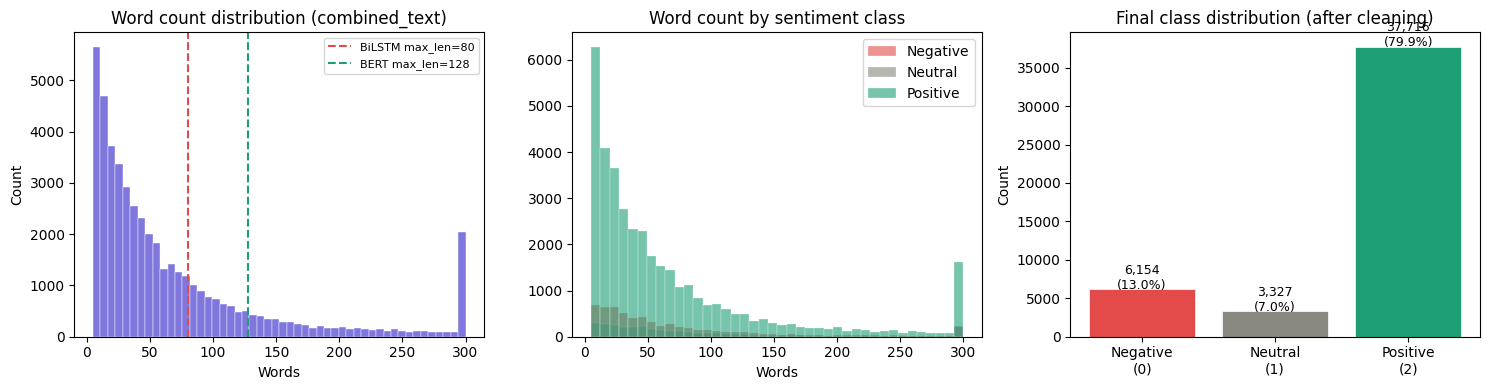

Saved: results/02_eda_text_length.png


In [7]:
# ── 2.5  EDA — TEXT LENGTH ANALYSIS ──────────────────────────
df['char_count'] = df['combined_text'].apply(len)

print("\n" + "=" * 60)
print("TEXT LENGTH STATISTICS (combined_text)")
print("=" * 60)
print(df['word_count'].describe().to_string())
print(f"\n90th percentile: {np.percentile(df['word_count'], 90):.0f} words")
print(f"95th percentile: {np.percentile(df['word_count'], 95):.0f} words")
print("→ max_length=80 tokens covers ~90% of reviews (BiLSTM)")
print("→ max_length=128 tokens covers ~95% of reviews (BERT/RoBERTa)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Word count distribution
axes[0].hist(df['word_count'].clip(upper=300), bins=50,
             color='#7F77DD', edgecolor='white', linewidth=0.3)
axes[0].axvline(80,  color='#E24B4A', linestyle='--', label='BiLSTM max_len=80')
axes[0].axvline(128, color='#1D9E75', linestyle='--', label='BERT max_len=128')
axes[0].set_title('Word count distribution (combined_text)')
axes[0].set_xlabel('Words')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

# Word count by class
for lbl, name, col in [(0,'Negative','#E24B4A'),(1,'Neutral','#888780'),(2,'Positive','#1D9E75')]:
    axes[1].hist(df[df['label']==lbl]['word_count'].clip(upper=300),
                 bins=40, alpha=0.6, label=name, color=col, edgecolor='white', linewidth=0.3)
axes[1].set_title('Word count by sentiment class')
axes[1].set_xlabel('Words')
axes[1].legend()

# Final class distribution
class_counts = df['label'].value_counts().sort_index()
bars = axes[2].bar(['Negative\n(0)', 'Neutral\n(1)', 'Positive\n(2)'],
                   class_counts.values,
                   color=['#E24B4A', '#888780', '#1D9E75'],
                   edgecolor='white', linewidth=0.5)
axes[2].set_title('Final class distribution (after cleaning)')
axes[2].set_ylabel('Count')
for bar, val in zip(bars, class_counts.values):
    pct = val / len(df) * 100
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/02_eda_text_length.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/02_eda_text_length.png")

In [9]:
# ── 2.6  CLASS DISTRIBUTION REPORT ───────────────────────────
print("\n" + "=" * 60)
print("FINAL CLASS DISTRIBUTION")
print("=" * 60)
for lbl, name in [(0,'Negative'),(1,'Neutral'),(2,'Positive')]:
    n = (df['label'] == lbl).sum()
    pct = n / len(df) * 100
    print(f"  {name} ({lbl}): {n:,} reviews ({pct:.1f}%)")
print(f"\nClass imbalance ratio (Positive/Neutral): "
      f"{class_counts[2]/class_counts[1]:.1f}×")




FINAL CLASS DISTRIBUTION
  Negative (0): 6,154 reviews (13.0%)
  Neutral (1): 3,327 reviews (7.0%)
  Positive (2): 37,716 reviews (79.9%)

Class imbalance ratio (Positive/Neutral): 11.3×


In [10]:
# ── 2.7  STRATIFIED TRAIN / VAL / TEST SPLIT ─────────────────
# Demo subset for Azure 15-min runtime
# Full dataset proportions preserved via stratify=label

TRAIN_SIZE = 8000
VAL_SIZE   = 1000
TEST_SIZE  = 1000
DEMO_SIZE  = TRAIN_SIZE + VAL_SIZE + TEST_SIZE

print("\n" + "=" * 60)
print(f"STRATIFIED SPLIT (demo subset = {DEMO_SIZE:,})")
print("=" * 60)

# Sample demo subset (stratified)
df_demo, _ = train_test_split(
    df, train_size=DEMO_SIZE, stratify=df['label'], random_state=RANDOM_STATE
)

# Split demo into train / temp
df_train, df_temp = train_test_split(
    df_demo, train_size=TRAIN_SIZE,
    stratify=df_demo['label'], random_state=RANDOM_STATE
)

# Split temp into val / test
df_val, df_test = train_test_split(
    df_temp, test_size=TEST_SIZE,
    stratify=df_temp['label'], random_state=RANDOM_STATE
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"  Train : {len(df_train):,} samples")
print(f"  Val   : {len(df_val):,} samples")
print(f"  Test  : {len(df_test):,} samples")

# Verify stratification — class proportions must be similar across splits
print("\nClass proportions per split (should be similar across all):")
for split_name, split_df in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    props = split_df['label'].value_counts(normalize=True).sort_index()
    print(f"  {split_name}: Neg={props.get(0,0):.3f}  Neu={props.get(1,0):.3f}  "
          f"Pos={props.get(2,0):.3f}")



STRATIFIED SPLIT (demo subset = 10,000)
  Train : 8,000 samples
  Val   : 1,000 samples
  Test  : 1,000 samples

Class proportions per split (should be similar across all):
  Train: Neg=0.130  Neu=0.070  Pos=0.799
  Val: Neg=0.130  Neu=0.071  Pos=0.799
  Test: Neg=0.131  Neu=0.070  Pos=0.799


In [11]:
# ── 2.8  COMPUTE CLASS WEIGHTS ────────────────────────────────
# Computed from TRAINING set only (not val/test — avoids data leakage)
# Formula: weight_c = n_samples / (n_classes × n_samples_c)
# Cite: sklearn.utils.class_weight.compute_class_weight

y_train = df_train['label'].values
cw_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=y_train
)
class_weights = {int(i): float(w) for i, w in enumerate(cw_array)}

print("\n" + "=" * 60)
print("CLASS WEIGHTS (computed from training set)")
print("=" * 60)
for lbl, name in [(0,'Negative'),(1,'Neutral'),(2,'Positive')]:
    print(f"  {name} ({lbl}): {class_weights[lbl]:.4f}×")
print("\nNeutral class receives the highest weight (smallest class).")
print("Positive class receives the lowest weight (largest class).")
print("These weights are passed into CrossEntropyLoss / FocalLoss for ALL models.")
print("Using IDENTICAL weights ensures performance differences reflect")
print("architecture, not loss function differences. (Ablation study hygiene)")


CLASS WEIGHTS (computed from training set)
  Negative (0): 2.5567×
  Neutral (1): 4.7281×
  Positive (2): 0.4171×

Neutral class receives the highest weight (smallest class).
Positive class receives the lowest weight (largest class).
These weights are passed into CrossEntropyLoss / FocalLoss for ALL models.
Using IDENTICAL weights ensures performance differences reflect
architecture, not loss function differences. (Ablation study hygiene)


In [13]:
# ── 2.9  SAVE ALL OUTPUTS ────────────────────────────────────
cols_to_save = ['combined_text', 'label', 'rating', 'word_count']

df_train[cols_to_save].to_csv('../data/train.csv', index=False)
df_val[cols_to_save].to_csv('../data/val.csv',   index=False)
df_test[cols_to_save].to_csv('../data/test.csv',  index=False)

with open('../data/class_weights.json', 'w') as f:
    json.dump(class_weights, f, indent=2)

print("\n" + "=" * 60)
print("SAVED")
print("=" * 60)
print(f"  data/train.csv        ({len(df_train):,} rows)")
print(f"  data/val.csv          ({len(df_val):,} rows)")
print(f"  data/test.csv         ({len(df_test):,} rows)")
print(f"  data/class_weights.json")
print(f"  results/02_eda_text_length.png")




SAVED
  data/train.csv        (8,000 rows)
  data/val.csv          (1,000 rows)
  data/test.csv         (1,000 rows)
  data/class_weights.json
  results/02_eda_text_length.png
